# Corporate-Jet-Index — a quantitative long/short teardown 🔬
### Long frugal / short jet-loving CEOs · HAC (Newey-West) *t* on the raw spread · a market-model α that is really a −0.45-beta BAB artifact · the founder-growth & survivorship confounds · costs + borrow · a synthetic faithful-engine / power control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Governance_discount%3F: Misattributed](https://img.shields.io/badge/Governance_discount%3F-Misattributed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). We take Yermack's (2006) *Flights of Fancy* result — jet-perk firms underperform ~4%/yr — at full strength and build the deployable long/short. The decisive move is **alpha vs beta**: the one statistic that clears *t* = 2 is a CAPM α manufactured by the long/short's **−0.45 beta** (frugal = low-beta staples, flyers = high-beta growth), i.e. the Frazzini-Pedersen betting-against-beta premium — not a governance discount. The raw, tradable spread is HAC *t* = **0.47**.

> ⚠️ **Data + label note.** True governance-perk panels aren't free; we use a hardcoded, labelled table of ~24 large-caps (heavy/frugal is the believers' framing, subjective at the margin). **Survivorship points *against* the claim**: the archetypal abusers (Tyco, WorldCom, Enron, Chesapeake) delisted to ~zero and can't enter a yfinance tape, so a survivor basket that *still* can't short the flyers is a conservative refutation. Real data: yfinance **monthly total-return** closes. Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from corporate_jet_index import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PRICES, FIRMS = data.load_real()
    PANEL = st.long_short_panel(PRICES, FIRMS, min_names=4)
    S = st.summarize(PANEL)
else:
    PRICES = FIRMS = PANEL = S = None
print("real price cache present:", HAVE_REAL,
      "| panel months:", (0 if PANEL is None else len(PANEL)))

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-06-30', 'n_firms': 24, 'n_heavy': 12, 'n_low': 12, 'fingerprint': 'ad201b5ed46c', 'n_months': 186, 'start': '2011-01', 'end': '2026-06', 'ls_ann': 2.11, 'ls_hac_t': 0.47, 'ls_naive_t': 0.48, 'ls_sharpe': 0.12, 'ls_lags': 4, 'heavy_x_ann': -0.34, 'low_x_ann': 1.76, 'alpha_ann': 8.81, 'alpha_t': 2.1, 'ls_beta': -0.45, 'heavy_beta': 1.31, 'low_beta': 0.87, 'cagr_low': 16.15, 'cagr_spy': 14.17, 'cagr_heavy': 12.19, 'ex_heavy_x': -3.83, 'ex_low_x': 1.76, 'ex_ls_ann': 5.8, 'ex_hac_t': 1.08, 'ex_alpha_ann': 12.08, 'ex_alpha_t': 2.22, 'gross_ann': 2.11, 'cost_ann': 0.24, 'borrow_ann': 0.5, 'net_ann': 1.36, 'winners': [('TSLA', 53.5), ('GOOGL', 10.1), ('META', 7.4), ('ANF', 4.7), ('GE', 1.9), ('ORCL', 1.6)], 'laggards': [('IEP', -14.1), ('CMCSA', -7.5), ('OXY', -5.7), ('LVS', -5.3), ('WYNN', -4.8), ('DIS', -3.9)], 'syn': [(0.0, -1.17, -0.49), (-80.0, 8.76, 3.53)]}


real price cache present: True | panel months: 186


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | Raw long/short (low−heavy, excess-of-mkt) **+2.1%/yr** at **HAC t = 0.47** (fails t≥2). Sign matches Yermack (ex-mega-cap flyers **-3.8%/yr** vs market) and survivorship biases *against* the claim ⇒ not nothing, but the tape can't certify it. |
| **Tradability** | `MIRAGE` | Net **+1.4%/yr** at t≈0.5; a −0.45-beta low-vol bet — one Tesla flips the short leg. |
| **Governance discount?** | `MISATTRIBUTED` | The lone t>2 is CAPM α **+8.8%/yr** (t = 2.10) driven by β = **-0.45** (heavy β 1.31 vs low β 0.87) — betting-against-beta, not jets. |

> 💡 In plain words: the frugal firms *did* out-compound the flyers — but that gap is (a) statistically indistinguishable from zero month-to-month, and (b) whatever is left after beta is just the reward for holding low-risk stocks and shorting high-risk ones. The jet is a passenger, not the pilot.

## 1 · The claim, steelmanned

For month $t$, form equal-weight basket returns $r^{\text{low}}_t$ (frugal) and $r^{\text{heavy}}_t$ (flyers, each name eligible only from the year after its perk is public), and the long/short in excess of the market $m_t=$ SPY:

$$\mathrm{LS}_t = (r^{\text{low}}_t - m_t) - (r^{\text{heavy}}_t - m_t) = r^{\text{low}}_t - r^{\text{heavy}}_t.$$

- **H₁ (Yermack).** $\mathbb{E}[\mathrm{LS}] > 0$ — frugal beats flyers, risk-adjusted.
- **H₂ (it's α, not β).** In $\mathrm{LS}_t = \alpha + \beta m_t + \varepsilon_t$, the $\alpha$ is positive **and not just a beta tilt**.
- **H₃ (deployable).** The spread survives a Newey-West *t*, costs, borrow, and dropping the mega-cap survivors.

We find **H₁ directionally supported but insignificant** (LS **+2.1%/yr**, HAC *t* = 0.47); **H₂ rejected** — the significant α (**+8.8%/yr**, *t* = 2.10) is an artifact of $\beta = -0.45$; **H₃ rejected** — the spread is a low-vol premium that one founder-growth name (Tesla) can flip. The claim is true as a *correlation with risk*, unproven as a *governance edge*.

## 2 · So what? — the object is α, not the raw spread

A raw long/short can be 'profitable' for a boring reason: if you are systematically **long low-beta and short high-beta**, you run a negative-beta book, and in a rising market a negative-beta portfolio earns a positive CAPM intercept *mechanically*. So the only governance-relevant quantity is the **beta-adjusted** α:

$$\hat\alpha,\ \hat\beta = \arg\min_{a,b}\sum_t\big(\mathrm{LS}_t - a - b\,m_t\big)^2,\qquad t_{\hat\alpha} = \frac{\hat\alpha}{\mathrm{se}_{\text{HAC}}(\hat\alpha)}.$$

The trap is reading a positive $\hat\alpha$ as 'governance works' when it is really $-\hat\beta\cdot\bar m$ leaking through — the low-volatility / betting-against-beta premium (Frazzini-Pedersen 2014; Baker-Bradley-Wurgler 2011). Our frugal basket ($\beta = 0.87$, defensive staples/retail) minus flyer basket ($\beta = 1.31$, growth) *is* a bet against beta, so the α it prints is the thing to be suspicious of, not to celebrate.

## 3 · How we'd know — the protocol

- **Perk table.** Hardcoded ~24 large-caps (ticker, heavy/low, public-year); **12** heavy / **12** low, as-of 2026-06-30, fingerprint `ad201b5ed46c`.
- **Eligibility / lag.** A heavy name enters the short only from **Jan of the year after** its perk is public (no look-ahead). Low names enter whenever priced.
- **Panel.** Monthly total-return closes; kept where both baskets have ≥4 eligible names ⇒ **186 months**, 2011-01 → 2026-06.
- **Signal test.** Newey-West (HAC, Bartlett) *t* on the monthly $\mathrm{LS}$ mean.
- **Alpha vs beta.** OLS $\mathrm{LS}=\alpha+\beta m+\varepsilon$ with a HAC *t* on $\alpha$; report the basket betas.
- **Confound stress tests.** Drop the mega-cap survivors (TSLA/META/GOOGL/ORCL); name the delisted abusers the tape *cannot* include.
- **Costs.** One-way 10 bps × ~10%/mo turnover on both legs + 50 bps/yr short borrow.
- **Positive control.** A deterministic monthly panel with a **plantable heavy-basket discount**; the engine must recover it and must NOT fabricate significance under the null.

## 4 · The teardown

### 4a · The raw spread — right sign, no significance

Long/short (low − heavy) in excess of the market, monthly, with its Newey-West *t*. The compounding gap is real; the *t* is a coin flip.

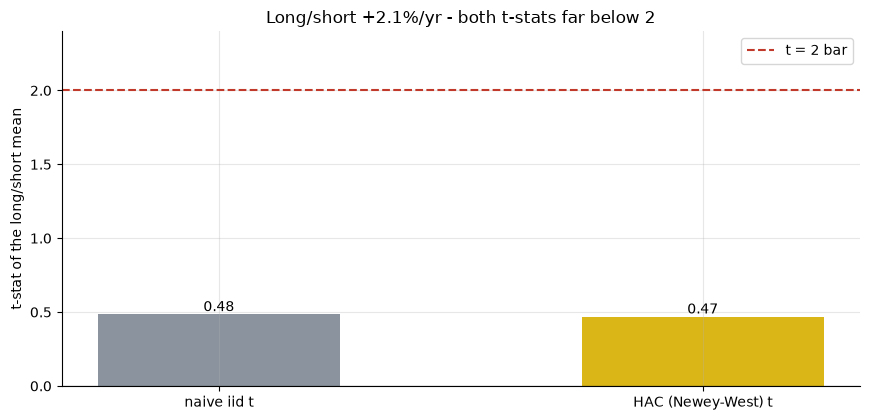

LS +2.11%/yr | naive t 0.48 | HAC t 0.47 (lags 4) -> fails t>=2


In [2]:
if HAVE_REAL:
    ls = PANEL['ls'].to_numpy(); hac = st.hac_tstat(ls)
    ann = st.annualize_mean(hac['mean'])*100; t = hac['t']; lags = hac['lags']
    naive = ls.mean()/(ls.std(ddof=1)/np.sqrt(len(ls)))
else:
    ann,t,lags,naive = R['ls_ann'], R['ls_hac_t'], R['ls_lags'], R['ls_naive_t']
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.bar(['naive iid t','HAC (Newey-West) t'], [naive, t], color=[GREY, AMBER], width=.5)
ax.axhline(2, ls='--', c=RED, label='t = 2 bar'); ax.axhline(0, c='k', lw=.8)
for i,v in enumerate([naive,t]): ax.annotate(f'{v:.2f}',(i,v),ha='center',va='bottom')
ax.set_ylim(0, 2.4); ax.set_ylabel('t-stat of the long/short mean')
ax.set_title(f'Long/short {ann:+.1f}%/yr - both t-stats far below 2'); ax.legend()
plt.tight_layout(); plt.show()
print(f'LS {ann:+.2f}%/yr | naive t {naive:.2f} | HAC t {t:.2f} (lags {lags}) -> fails t>=2')

> 💡 In plain words: **+2.1%/yr** at HAC *t* = **0.47** (the naive *t* is barely higher at 0.48, so autocorrelation isn't hiding an edge). With ~24 names and monthly scatter, a couple-of-point spread is deep inside its standard error. H₁ is directionally there and statistically absent.

### 4b · Alpha vs beta — the significant number is a beta artifact

Regress the long/short on the market. The intercept α clears *t* = 2 — but look at the slope: a **negative beta**. The α is what a short-beta book earns in a bull market, not a governance premium.

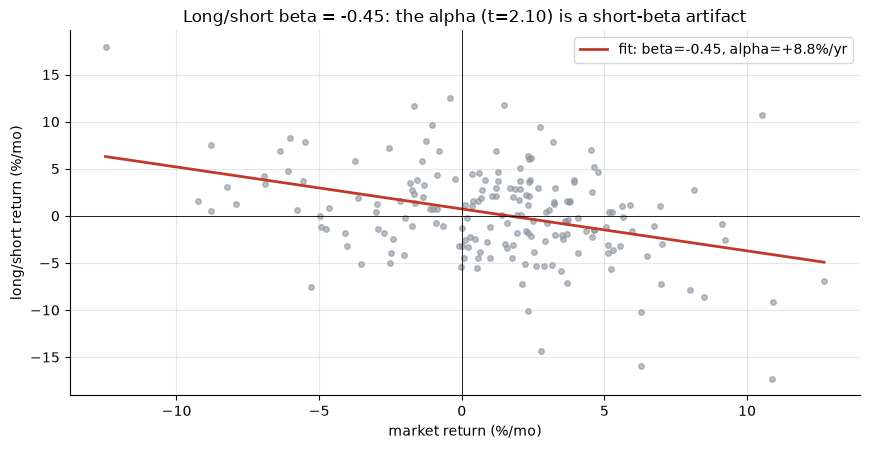

alpha +8.8%/yr (HAC t=2.10) | LS beta -0.45 -> negative beta manufactures the alpha


In [3]:
if HAVE_REAL:
    mkt = st.monthly_returns(PRICES)['SPY'].reindex(PANEL.index).to_numpy()
    mm = st.market_model_alpha(PANEL['ls'].to_numpy(), mkt)
    a_ann = st.annualize_mean(mm['alpha'])*100; ta = mm['t_alpha']; beta = mm['beta']
    x = mkt*100; y = PANEL['ls'].to_numpy()*100
else:
    a_ann,ta,beta = R['alpha_ann'], R['alpha_t'], R['ls_beta']
    rng=np.random.default_rng(1); x=rng.normal(0.9,4.3,R['n_months']); y=beta*x+R['alpha_ann']/12+rng.normal(0,3,R['n_months'])
fig, ax = plt.subplots(figsize=(8.8, 4.6))
ax.scatter(x, y, s=16, color=GREY, alpha=.6)
xs = np.linspace(x.min(), x.max(), 50)
ax.plot(xs, beta*xs + a_ann/12, c=RED, lw=2, label=f'fit: beta={beta:+.2f}, alpha={a_ann:+.1f}%/yr')
ax.axhline(0, c='k', lw=.6); ax.axvline(0, c='k', lw=.6)
ax.set_xlabel('market return (%/mo)'); ax.set_ylabel('long/short return (%/mo)')
ax.set_title(f'Long/short beta = {beta:+.2f}: the alpha (t={ta:.2f}) is a short-beta artifact'); ax.legend()
plt.tight_layout(); plt.show()
print(f'alpha {a_ann:+.1f}%/yr (HAC t={ta:.2f}) | LS beta {beta:+.2f} -> negative beta manufactures the alpha')

> 💡 In plain words: the down-sloping fit is the whole story. The long/short has $\beta = -0.45$ because the frugal basket ($\beta = 0.87$) is defensive and the flyer basket ($\beta = 1.31$) is aggressive. Over a market that rose ~14%/yr, a −0.45-beta book *must* print a positive intercept. That α is **betting-against-beta**, a premium the desk has priced a hundred times — it has nothing to do with corporate jets.

### 4c · The founder-growth & survivorship confounds

Two forces pull in opposite directions. **Survivorship** removes the delisted abusers (which would *help* the short) — yet the surviving flyers are **founder-growth winners** (which *hurt* it). Drop the four mega-cap survivors and the heavy basket finally underperforms the market by ~4% — Yermack's number — but the spread is *still* insignificant and *still* a beta artifact.

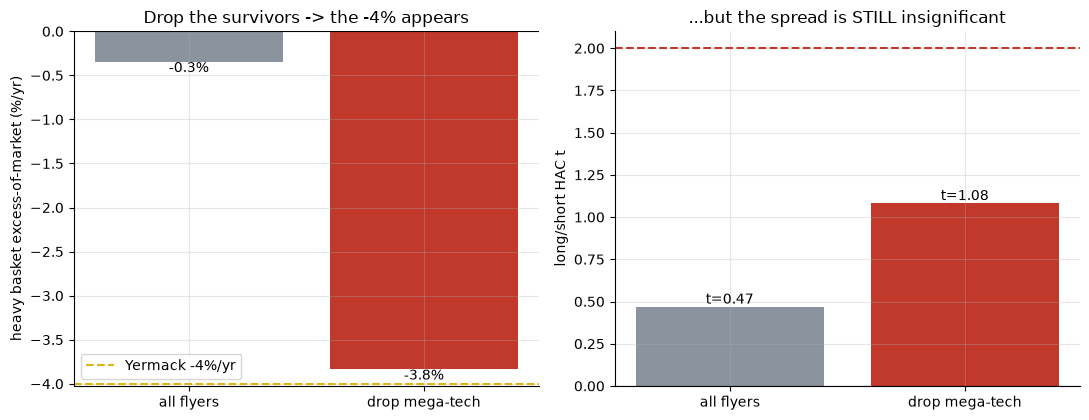

all flyers: heavy -0.3%/yr, HAC t 0.47 | ex-mega-tech: heavy -3.8%/yr, HAC t 1.08


In [4]:
if HAVE_REAL:
    firms2 = [f for f in FIRMS if f['ticker'] not in ('TSLA','META','GOOGL','ORCL')]
    s2 = st.summarize(st.long_short_panel(PRICES, firms2, min_names=3))
    full = (S['heavy_x_ann']*100, S['ls_mean_ann']*100, S['ls_hac_t'])
    exmt = (s2['heavy_x_ann']*100, s2['ls_mean_ann']*100, s2['ls_hac_t'])
else:
    full = (R['heavy_x_ann'], R['ls_ann'], R['ls_hac_t'])
    exmt = (R['ex_heavy_x'], R['ex_ls_ann'], R['ex_hac_t'])
fig, (a1,a2) = plt.subplots(1,2, figsize=(11.0,4.3))
a1.bar(['all flyers','drop mega-tech'], [full[0], exmt[0]], color=[GREY, RED])
a1.axhline(0, c='k', lw=.8); a1.axhline(-4, ls='--', c=AMBER, label="Yermack -4%/yr")
a1.set_ylabel('heavy basket excess-of-market (%/yr)'); a1.set_title('Drop the survivors -> the -4% appears'); a1.legend()
for i,v in enumerate([full[0],exmt[0]]): a1.annotate(f'{v:+.1f}%',(i,v),ha='center',va='top' if v<0 else 'bottom')
a2.bar(['all flyers','drop mega-tech'], [full[2], exmt[2]], color=[GREY, RED])
a2.axhline(2, ls='--', c=RED); a2.axhline(0, c='k', lw=.8)
a2.set_ylabel('long/short HAC t'); a2.set_title('...but the spread is STILL insignificant')
for i,v in enumerate([full[2],exmt[2]]): a2.annotate(f't={v:.2f}',(i,v),ha='center',va='bottom')
plt.tight_layout(); plt.show()
print(f'all flyers: heavy {full[0]:+.1f}%/yr, HAC t {full[2]:.2f} | ex-mega-tech: heavy {exmt[0]:+.1f}%/yr, HAC t {exmt[2]:.2f}')

> 💡 In plain words: strip out Tesla/Meta/Alphabet/Oracle and the flyers lag the market by **-3.8%/yr** — spookily close to the paper. But (a) that's a snooped subset, and (b) the spread is *still* only HAC *t* = **1.08** with the same low-beta α (**+12.1%/yr**, *t* = 2.22). The delisted abusers the tape can't hold would push the *other* way — so even this survivor-biased, hand-trimmed version can't manufacture a real governance short.

### 4d · Faithful-engine & power control — we know the truth here

A deterministic monthly panel (12 heavy / 12 low, **equal betas** so the null spread is centered on zero) with a **plantable heavy-basket discount**. With **no** discount the HAC *t* must stay inside ±2; with a large planted discount it must light up positive.

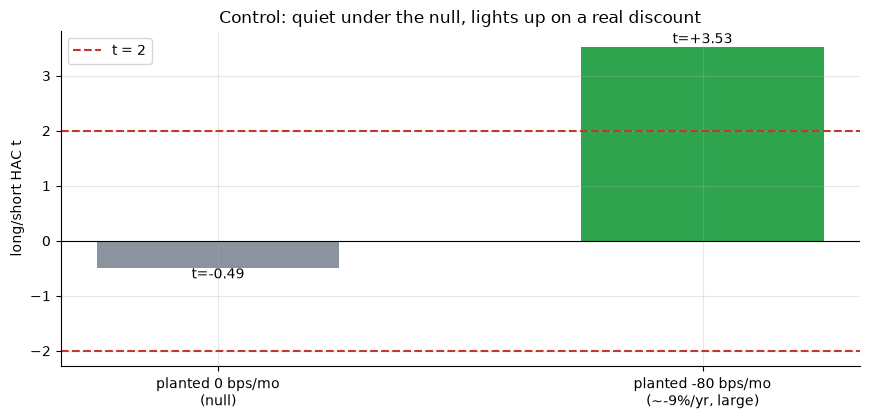

planted +0 bps/mo: LS -1.17%/yr  HAC t = -0.49
planted -80 bps/mo: LS +8.76%/yr  HAC t = +3.53


In [5]:
res = []
for edge in (0.0, -80.0):
    syn = data.synthetic_panel(alpha_bps_month=edge, seed=745)
    h = st.hac_tstat(syn['ls'])
    res.append((edge, st.annualize_mean(h['mean'])*100, h['t']))
fig, ax = plt.subplots(figsize=(8.8, 4.3))
labels = ['planted 0 bps/mo\n(null)', 'planted -80 bps/mo\n(~-9%/yr, large)']
ts = [r[2] for r in res]
ax.bar(labels, ts, color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t = 2'); ax.axhline(-2, ls='--', c=RED); ax.axhline(0, c='k', lw=.8)
for i,t in enumerate(ts): ax.annotate(f't={t:+.2f}',(i,t),ha='center',va='bottom' if t>=0 else 'top')
ax.set_ylabel('long/short HAC t'); ax.set_title('Control: quiet under the null, lights up on a real discount'); ax.legend()
plt.tight_layout(); plt.show()
for e,a,t in res: print(f'planted {e:+.0f} bps/mo: LS {a:+.2f}%/yr  HAC t = {t:+.2f}')

> 💡 In plain words: with **no** planted discount the control's HAC *t* is **-0.49** (no false positive from 186 months); a large −80 bps/mo discount drives it to **3.53**. So the engine is honest and powered — and the real tape's HAC *t* of **0.47** is exactly what an *absent, survivor-suppressed, beta-confounded* effect looks like. The machinery isn't the problem; the claim is.

## 5 · The verdict

- **Signal `WEAK`** — raw long/short **+2.1%/yr** at **HAC t = 0.47** (naive t 0.48), fails t ≥ 2. The sign matches Yermack (ex-mega-cap flyers -3.8%/yr vs market ≈ his −4%) and **survivorship biases *against*** the claim, so it isn't a hard zero — but literature + right sign on a sub-2 tape ⇒ WEAK, not REAL.
- **Tradability `MIRAGE`** — net **+1.4%/yr** at t≈0.5; it is a −0.45-beta low-vol bet, and one founder-growth survivor (Tesla) flips the short leg. Not NAV-scale, not sign-stable.
- **Governance discount? `MISATTRIBUTED`** — the only t>2 is CAPM α **+8.8%/yr** (t = 2.10) driven by β = **-0.45** (heavy β 1.31 vs low β 0.87) — the betting-against-beta premium, not a jet red flag.

## 6 · Could you trade it? — costs, borrow, and the single-name risk

The operational truth: a low-single-digit gross spread, most of it a factor you can rent cheaply, all of it hostage to a handful of founder-growth names on the short leg.

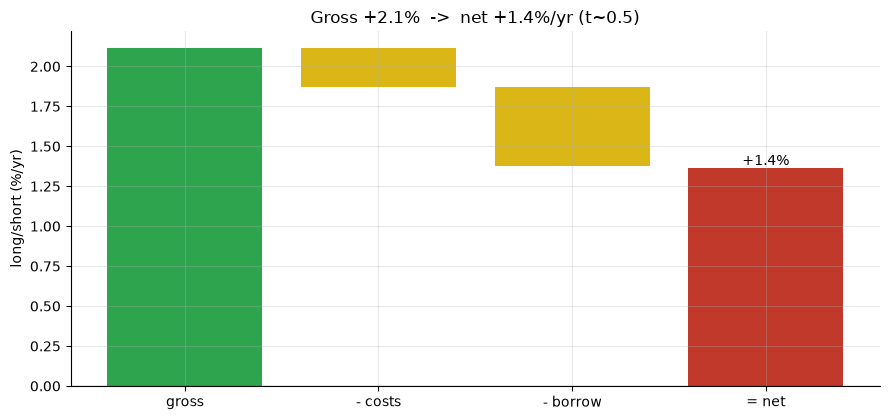

gross +2.1%/yr | costs -0.2 | borrow -0.5 | net +1.4%/yr — a low-vol premium, not an edge


In [6]:
if HAVE_REAL:
    nc = st.net_of_costs(PANEL['ls'])
    g,cst,bor,net = nc['gross_ann']*100, nc['rebal_cost_ann']*100, nc['borrow_ann']*100, nc['net_ann']*100
else:
    g,cst,bor,net = R['gross_ann'], R['cost_ann'], R['borrow_ann'], R['net_ann']
fig, ax = plt.subplots(figsize=(9.0, 4.3))
steps = ['gross', '- costs', '- borrow', '= net']
vals = [g, -cst, -bor, None]; running=g; bottoms=[0]; heights=[g]
for v in vals[1:3]:
    bottoms.append(running+v if v<0 else running); heights.append(abs(v)); running+=v
ax.bar(0, g, color=GREEN); ax.bar(1, cst, bottom=g-cst, color=AMBER); ax.bar(2, bor, bottom=g-cst-bor, color=AMBER)
ax.bar(3, net, color=RED)
ax.axhline(0, c='k', lw=.8); ax.set_xticks(range(4)); ax.set_xticklabels(steps)
ax.set_ylabel('long/short (%/yr)'); ax.set_title(f'Gross {g:+.1f}%  ->  net {net:+.1f}%/yr (t~0.5)')
ax.annotate(f'{net:+.1f}%', (3,net), ha='center', va='bottom')
plt.tight_layout(); plt.show()
print(f'gross {g:+.1f}%/yr | costs -{cst:.1f} | borrow -{bor:.1f} | net {net:+.1f}%/yr — a low-vol premium, not an edge')

> 💡 In plain words: after frictions you're left with a **low-vol factor** you could buy as an ETF, wrapped in idiosyncratic single-name risk (short Tesla for a decade — no thanks). There is no jet-specific residual to capture. **The most vivid part of the story — famous flying founders — is exactly what makes the short both dangerous and empty.**

## 7 · Going further

- **The governance-alpha graveyard.** Gompers-Ishii-Metrick (2003) governance long/short looked like huge alpha; Bebchuk-Cohen-Wang (2013) showed it **decayed to zero out of sample**. The jet sort is the same species — a governance narrative whose only significant statistic is a risk factor.
- **Resurrect the delisted.** Rebuild the heavy basket with the *bankrupt* abusers (Tyco, WorldCom, Enron, Chesapeake) on their real paths to zero — the honest way to see whether Yermack's discount lives where the survivor tape can't look.
- **Beta-neutralise.** Re-run the long/short beta-hedged or in a low-vol-matched universe; if *any* jet signal clears *t* = 2 once the risk profile is equalised, that would be news.
- **Bigger panel, real disclosure dates.** Swap the hardcoded table for a full perquisite-disclosure panel (hundreds of firms, exact DEF 14A dates); the error bars tighten, but the beta and founder-growth confounds won't vanish on their own.

*The reproducible core is offline and deterministic; the perk table is an explicit hardcoded, labelled stand-in, survivor-biased *against* the claim. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*